# Lab 078 · Message passing: from a join to a GCN

**Core:** derive one-hop embeddings. **Research route:** reproduce the full Cora Table 2 GCN experiment with an explicit framework-deviation ledger. Read and implement before running the full experiment. All code is visible below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Start cold · retrieve before reading



Without opening Lesson 77, explain why a deeper model cannot recover information missing from its input. Then draw a customer → order → merchant path. How many edges separate the customer from a merchant attribute? Write your answer before continuing.

**Today’s win:** compute every node’s new vector after one synchronous round of message passing, then explain precisely what makes a GCN layer different from a plain mean. The core route is sections 1–5 plus the three lab TODOs. The complete Cora experiment is a separate research route.



## 1 · A join becomes a message

> **In plain terms.** Each node reads its neighbors’ old vectors, combines what it receives, and updates its own vector. Every node does this from the same snapshot.

A **node** is an entity represented by a row. An **edge** is a permitted connection between entities. A **node feature vector** is a list of numeric measurements for that entity. A **hidden state**, also called an embedding here, is the vector carried between layers. It need not be learned in a hand calculation.

**Routing convention.** An edge `(source, destination)` sends information from source to destination. A database foreign key tells us how rows connect; we must still choose the direction in which information flows. Order → customer sends order information to its customer. Bidirectional flow requires both directions.

**Worked example.** Nodes A, B, C and D start with scalar states `[2,4,8,10]`. The graph is the undirected chain A—B—C plus isolated D. Store each chain edge in both directions. There are no self-edges in this first example.

For B, incoming messages are A’s 2 and C’s 8. Their mean is `(2+8)/2 = 5`. Our illustrative update takes half the old self-state and half the neighbor mean: `B_new = max(0, .5×4 + .5×5) = 4.5`. The maximum with zero is **ReLU**, a function that keeps positive values and replaces negative ones with zero. These coefficients are fixed teaching choices, not trained parameters.




<figure class="mp-figure"><div tabindex="0">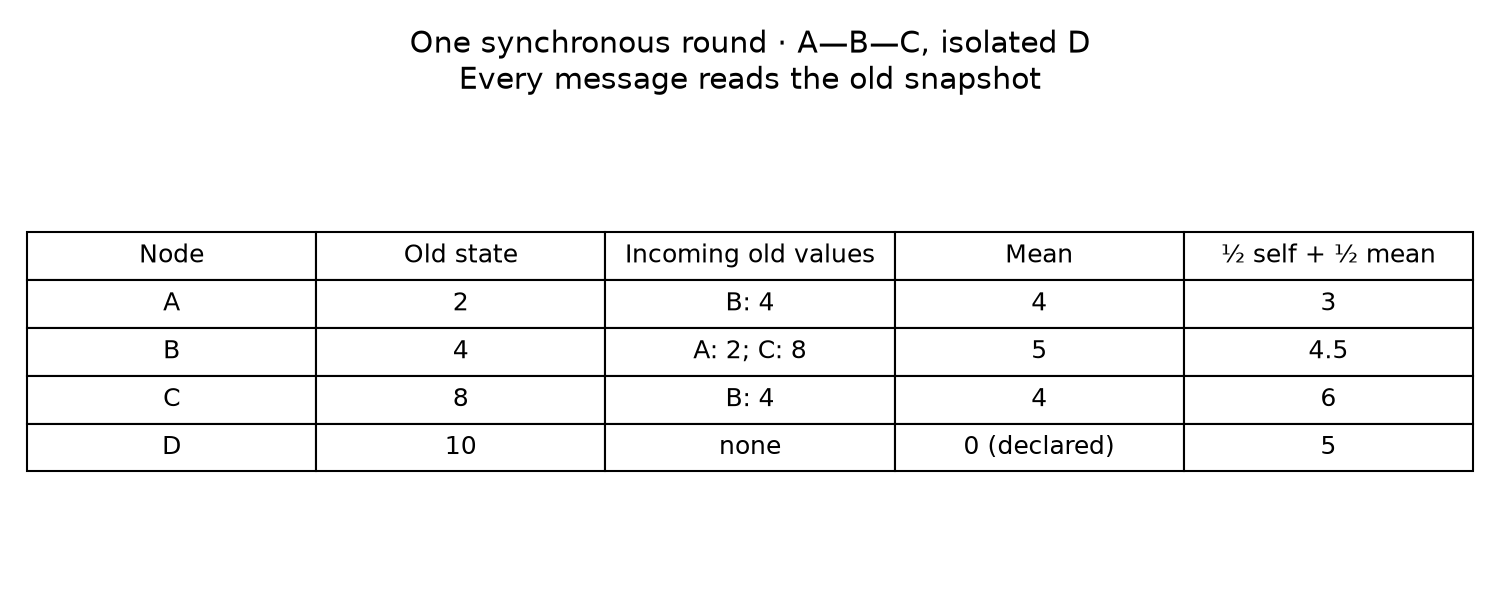</div><figcaption>Synchronous hand fixture: old states, incoming messages, means and updated outputs. D has no incoming messages; its declared empty mean is zero.</figcaption></figure>

**All nodes.** Incoming means are `[4,5,4,0]`; updated states are `[3,4.5,6,5]`. D’s neighbor mean is defined as zero, so its update is 5. An isolated node does not necessarily retain its state: that depends on the update rule. A self-loop would change this calculation.

**Synchronous means one shared old snapshot.** Updating A in place before B would make B read A=3, producing 4.75 instead of 4.5. That error makes node storage order affect the result. Keep input and output arrays separate.



## 2 · The MPNN abstraction

> **In plain terms.** A learned message function decides what to send. A reduction combines incoming messages. A learned update decides what to keep.

Gilmer and colleagues organize message passing around these equations:

```text
m_v^(t+1) = SUM over w in N(v) of M_t(h_v^t, h_w^t, e_vw)
h_v^(t+1) = U_t(h_v^t, m_v^(t+1))
graph_prediction = R({h_v^T : v in graph})
```

Here `v` is the receiving node, `w` is a neighbor, and `N(v)` is its neighbor collection. `t` numbers rounds; `T` is the final round. `h` is a node state; `e` is an edge feature such as relation type. `M` produces a message, `SUM` reduces messages, and `U` updates the state. `R` is a **readout** that combines final states when the target belongs to the whole graph, as with a molecule. Node classification instead predicts separately from each final node state. See [Gilmer et al., §2](https://proceedings.mlr.press/v70/gilmer17a.html).

Our mean fixture is a simple message-passing variant: send `h_w`, sum the messages and divide by incoming count, then apply the stated self/neighbor update. It is not the paper’s full molecular architecture. The paper’s abstract sum formulation and this explicit mean must not be conflated.

**What becomes learned?** Replace fixed scalar coefficients with matrices, for example `ReLU(h_v W_self + m_v W_neighbor + b)`. With states of width `d` and output width `k`, both matrices have shape `d×k`, the bias has `k` entries, and every node shares these parameters. A supervised loss changes the shared parameters through gradients. It does not change the identity of eligible neighbors unless graph construction is itself part of a separately specified model.

**Order and identity.** Summation or mean is invariant to neighbor enumeration. Renaming all nodes and reindexing their features and edges together merely renames the outputs: this is **permutation equivariance**. The node outputs move with the nodes; they are not one invariant graph vector. An invariant graph readout would remain unchanged under that relabeling.

**A reduction still loses information.** `[2]` and `[2,2]` have the same mean. More graph access does not guarantee that a reducer preserves the target signal. This is the same information-interface issue as [Lesson 77](../lessons/0077-single-table-ceiling.html).



## 3 · Reach and point-in-time safety

> **In plain terms.** One layer carries a neighbor’s current information one edge. A second layer can carry information that neighbor received from farther away.

On A—B—C, changing C from 8 to 20 leaves A’s first update at 3. But B’s first update rises from 4.5 to 7.5, so A’s second update rises from 3.75 to 5.25. These numbers follow the same synchronous rule. A **receptive field** is the set of input nodes that can influence an output. With this fixed graph and local updates, after two layers A can depend on C.



**Relational connection.** A manual `GROUP BY customer_id` with `AVG(amount)` performs identity routing and reduction. A graph layer generalizes the message and update functions so supervised training can learn which combinations matter. It does not automatically generalize eligibility rules.

**Time boundary.** Before every hop, restrict nodes, edges and attributes to information available at the prediction cutoff. An event dated before the cutoff but ingested later is unavailable. A two-hop merchant feature computed from future transactions can leak even when the direct order edge is old. Recompute degree normalization on the eligible graph; future edges can otherwise change today’s weights without sending their feature values.

**Cora is a different protocol.** The research lane is transductive: all graph structure and node features are supplied during training, while only training-node labels enter the loss. Validation labels determine stopping. Test labels are used only after stopping. This is the declared benchmark; it is not evidence of temporal database safety.



## 4 · GCN: a weighted sum, not an ordinary mean

> **In plain terms.** GCN adds each node to its own neighborhood and weights a message using both endpoint degrees.

Let `A[v,w]=1` when w sends to v. For the undirected GCN graph, A is symmetric. Add the identity matrix `I`, whose diagonal is one: `A_tilde=A+I`. Let `d_v` count node v’s neighbors including that self-loop. The normalized support matrix has entries `S[v,w]=A_tilde[v,w]/sqrt(d_v d_w)`. A layer is `H_new = ReLU(S H W)`. `H` has shape `N×d`, `W` has shape `d×k`, and `S` is `N×N`. Thus outputs have shape `N×k`. These are [Kipf and Welling’s Eq. 2](https://arxiv.org/html/1609.02907v4#S2).

**Worked example, same chain.** Augmented degrees are `[2,3,2,1]`. Set W=1 to isolate normalization. B receives `2/sqrt(6)` from A, `4/3` from itself, and `8/sqrt(6)` from C. Total: approximately **5.415816**. A receives `2/2 + 4/sqrt(6)` ≈ **2.632993**. C receives `8/2 + 4/sqrt(6)` ≈ **5.632993**. D retains 10 through its sole self-loop.



<figure class="mp-figure"><div tabindex="0">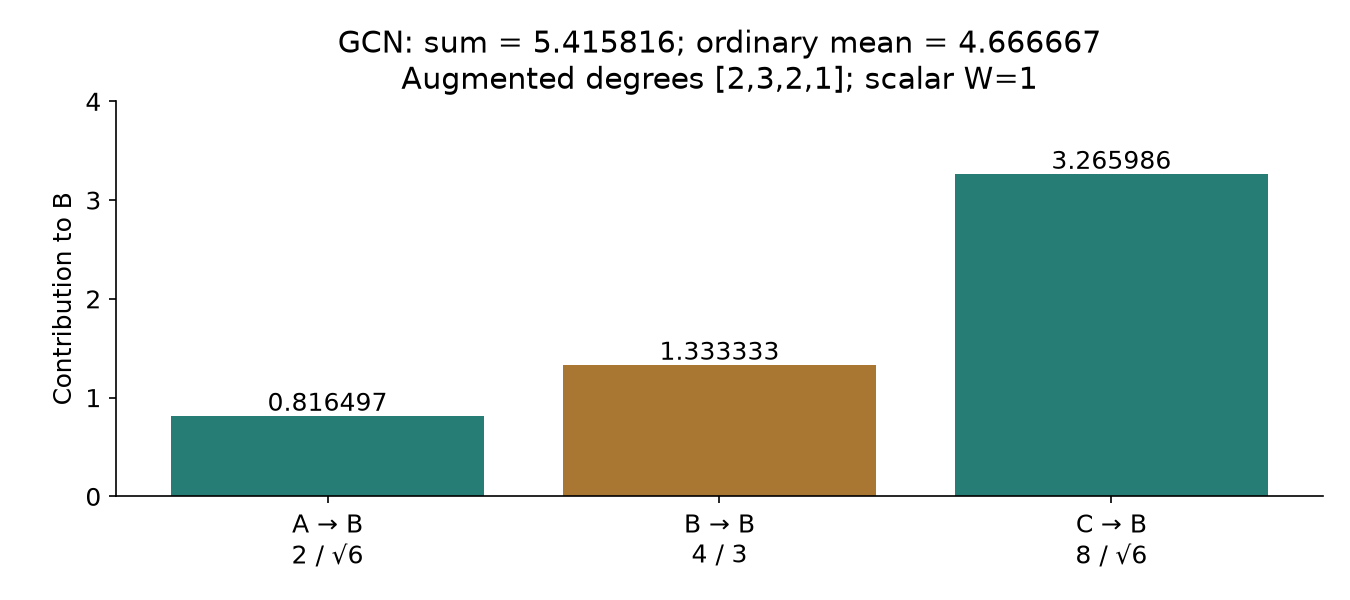</div><figcaption>Same graph, different operator: symmetric GCN contributions to B, with W=1. Self-loop included; weights do not sum to one.</figcaption></figure>

**Why not call this a mean?** B’s weights sum to `2/sqrt(6)+1/3` ≈ 1.149830, not 1. A mean including self would be `(2+4+8)/3` ≈ 4.666667. Symmetric normalization and a row-normalized mean are different operators. The paper motivates this support through an approximation to spectral graph filtering and a renormalization step; that derivation belongs to the deeper GCN lesson. Here you must reproduce the actual local operator.



## 5 · Model architecture: the complete Cora GCN

<figure class="mp-figure"><div tabindex="0">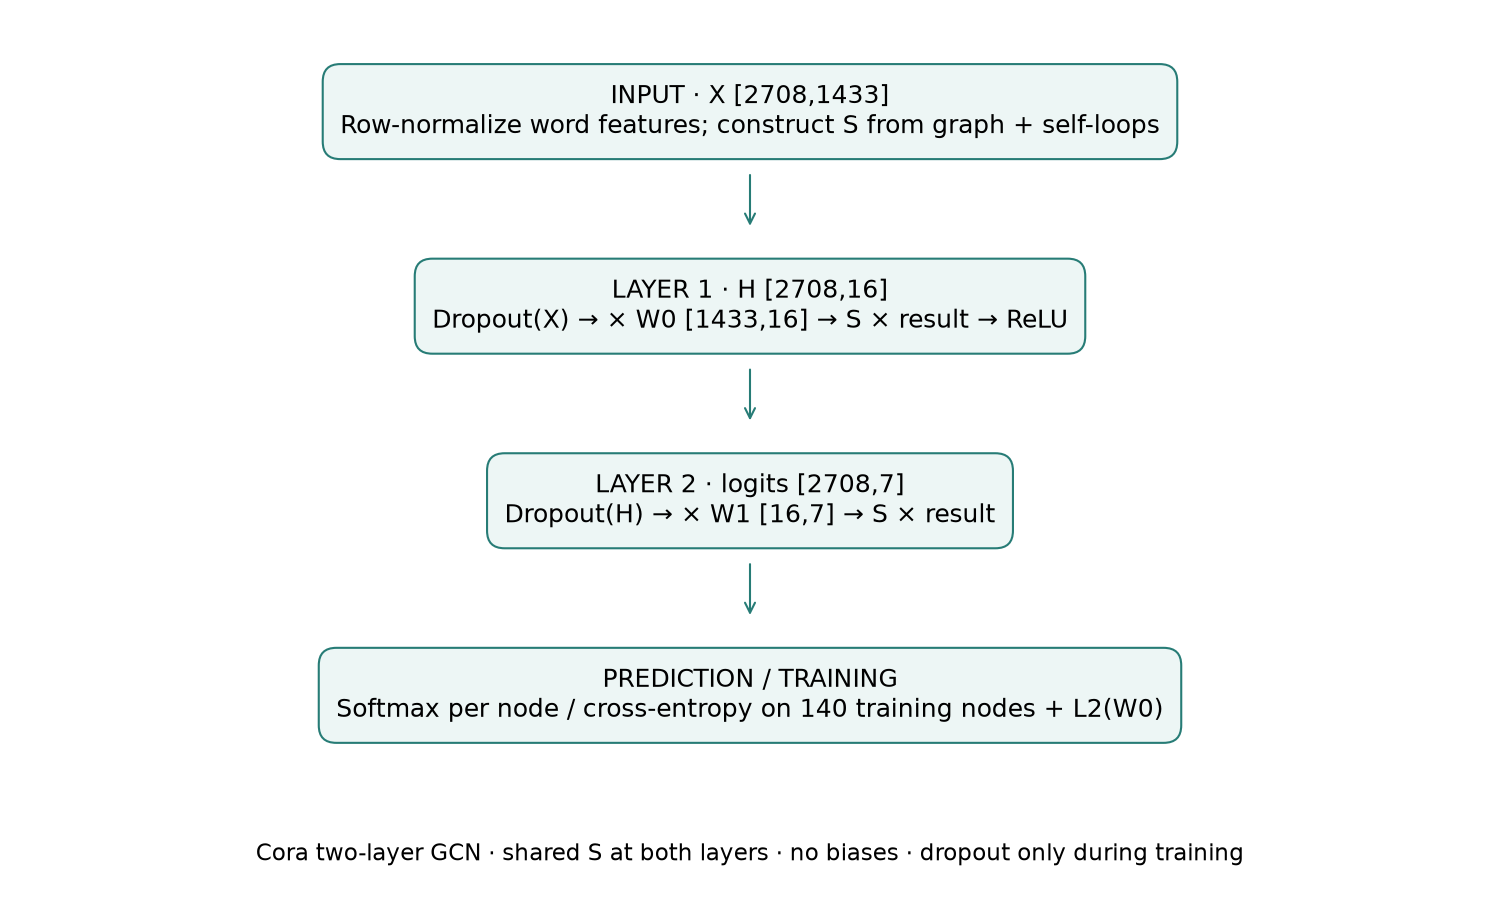</div><figcaption>Full Cora GCN: feature normalization, two graph layers and node prediction/loss. Dropout is active during training only.</figcaption></figure>

**Input.** Cora supplies 2,708 document nodes, 1,433 bag-of-words features and seven target classes. Row normalization divides each document’s feature vector by its feature sum; zero rows remain zero. Citation links are treated as undirected, binary edges. Self-loops and symmetric normalization produce S. The raw graph has no self-edges (verified). The reproduction binarizes duplicate links, follows the released adjacency construction and adds identity exactly once.

**First layer.** During training, feature dropout randomly zeroes entries and scales retained entries by `1/(1−p)` with p=.5. Multiply by `W0[1433,16]`, route through S, and apply ReLU. The hidden matrix is `[2708,16]`.

**Second layer.** Apply hidden dropout, multiply by `W1[16,7]`, then route through S again. Output logits have shape `[2708,7]`. A **logit** is an unnormalized class score. Softmax turns each row into class probabilities. Cross-entropy rewards the true class; the implementation consumes logits directly for numerical stability. Neither layer has a bias. There is no pretrained checkpoint: both weights start from Glorot uniform initialization, with bounds determined by input and output widths.

**Training boundary.** Full-graph forward passes expose all permitted features. The loss averages cross-entropy over only 140 training nodes and adds `.0005 × .5 × sum(W0²)`. The first-layer penalty matches TensorFlow’s half-squared-norm convention. Adam updates both matrices. At inference, dropout is disabled; the graph operations and learned matrices stay the same. There is no graph-level pooling head.



## 6 · Full reproduction, with the remaining differences visible

The named target is **GCN, Cora, fixed split, Table 2**: paper accuracy **81.5%**, averaged across 100 random initializations. This is one complete experiment, not the whole paper. The [released implementation](https://github.com/tkipf/gcn/tree/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81) fixes the data split and configuration. We pin its source and raw dataset bytes with SHA-256 hashes.

| Item | Executed contract |
|---|---|
| Data | Full released Cora, all 2,708 nodes; no subsampling |
| Labels | 140 train (20 per class), 500 validation, 1,000 test |
| Architecture | Two bias-free GCN layers, 16 hidden units, ReLU |
| Optimizer | Adam, learning rate .01, betas .9/.999, epsilon 1e-8 |
| Regularization | Dropout .5 at both layer inputs; first-weight L2 only |
| Schedule | At most 200 epochs; current validation loss vs prior-ten mean |
| Selection | Released stopping rule; last weights, no best-checkpoint restore |
| Replication | Seeds 0–99; fixed split; mean, sample SD and standard error |

**A source mismatch you should notice.** The paper says ten consecutive epochs without validation improvement. The release compares current validation loss against the mean of the preceding ten losses once the zero-based epoch exceeds ten. We reproduce the released rule and name it explicitly. Validation loss includes the regularization term. Never quietly replace this with modern patience/best-checkpoint training and call it identical.

**Author-reference results — executed locally, not your current kernel output.**

| Experiment | Seeds | Mean accuracy | Sample SD | Standard error |
|---|---:|---:|---:|---:|
| Full Cora release-protocol port | 100 | 81.401% | 0.658 percentage points | 0.066 percentage points |
| Paper Table 2 target | 100 | 81.5% | Not stated in this row | Not stated in this row |

Local minus paper: -0.099 percentage points. No hyperparameters were changed after reading the test results. [All seed results](../labs/_paper_l078_results.json).

<figure class="mp-figure"><div tabindex="0">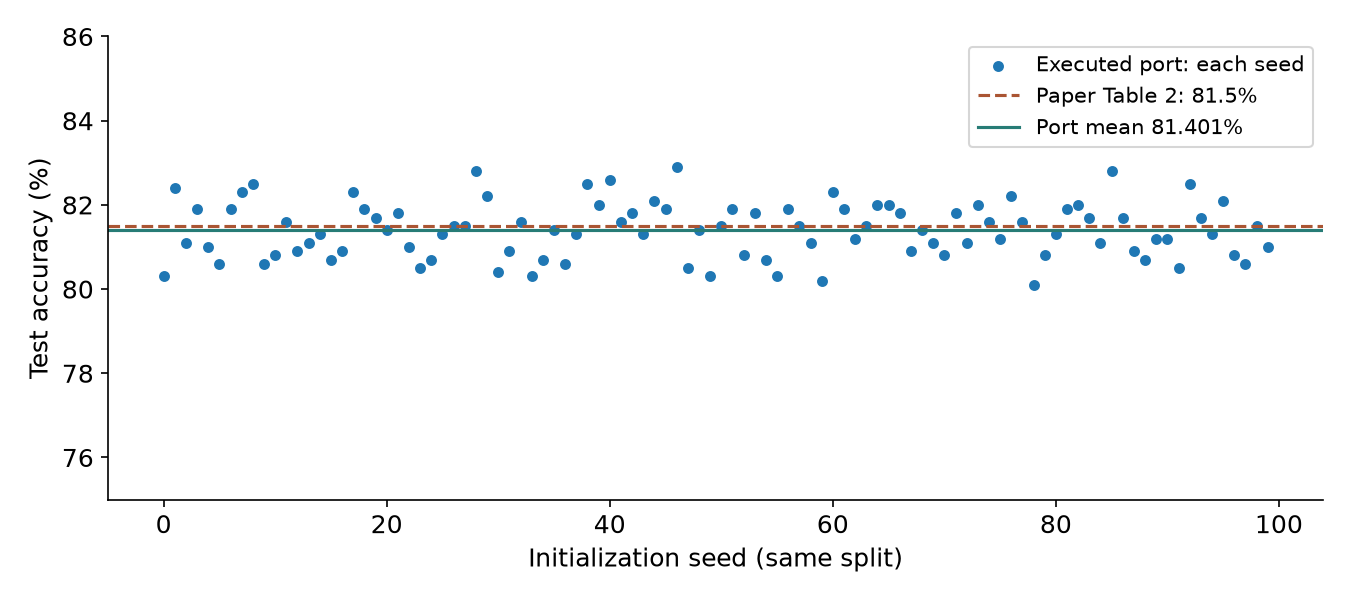</div><figcaption>Author-reference measurement: 100 initializations on one fixed Cora split. Each dot is a measured port run, not a new dataset. Dashed line is the cited paper target.</figcaption></figure>

> **Scope check.** This is a full-data, full-schedule PyTorch port of the released Cora experiment. TensorFlow 1 and PyTorch differ in random-number streams and Adam’s numerical details; the paper does not publish the identities of its 100 seeds. Similar accuracy does not establish bitwise or original-framework parity. The other datasets, baselines and Gilmer QM9 molecular experiments are **NOT_RUN** here. The hand mean example is not a molecular-result reproduction.

**Re-run from the repository root:**

```bash
.venv/bin/python labs/_verify_l078.py
.venv/bin/python labs/_run_l078.py --seeds 100
.venv/bin/python labs/_build_l078.py
```

Use [the reproduction contract](../labs/l078-reproduction.md) for a fresh environment and the [source manifest](../labs/_sources_l078.json) for file identities. The notebook exposes every part of preprocessing, the model and the training loop. The post-EXIT cell runs this same complete protocol from the functions visible in your kernel.



## 7 · Lab: derive, implement, intervene

[Open the lab](../labs/html/0078-message-passing-preview.html) · [Download notebook](../labs/0078-message-passing-preview.ipynb) · [Reference card](../reference/0078-message-passing-preview.html).

1. **TODO:** implement mean incoming messages, including an empty neighborhood. CHECK the four-node fixture and reversed edge order.
2. **TODO:** implement the synchronous self/neighbor update. CHECK all four outputs and node-permutation equivariance.
3. **TODO:** implement symmetric GCN normalization. CHECK the hand weights and isolate why it differs from row mean.
4. **Intervene:** change only C. Predict which first- and second-round outputs change before running the supplied experiment.
5. **EXIT:** explain message, reduction, update and readout in your own words. Give one temporal leakage path and show the boundary that blocks it. Explain why the Cora test graph is visible but its labels are not training inputs.



**Research-route interpretation.** Read the per-seed table and plot, compare the local mean to 81.5%, and identify two differences that prevent an exact parity claim. The standard error describes initialization variability on one fixed graph/split. It does not measure generalization across new graphs or temporal deployments. Do not tune on this comparison; a new protocol is a separate experiment.

**Tomorrow:** compute B’s mean and GCN outputs without notes. **One week later:** derive why node relabeling reorders outputs, then construct a graph where mean loses multiplicity. Ask your tutor follow-up questions or send your hand calculation and notebook outputs for review. Lesson creation does not imply learner completion.

**Primary reading:** [Gilmer et al., §2](https://proceedings.mlr.press/v70/gilmer17a.html) for the organizing abstraction; [Kipf and Welling, §2–3 and §5–6](https://arxiv.org/html/1609.02907v4) for the layer and the Cora experiment. Return to [Lesson 76’s encoder–predictor stack](../lessons/0076-encoder-predictor-stack.html) to locate these layers; L081 develops MPNNs further.


## PROVIDED · imports

The core functions below operate on arrays. Edges are source/destination pairs. Avoid in-place updates: every destination must read the same old snapshot.

In [ ]:
from pathlib import Path
import hashlib
import json
import pickle
import urllib.request
import numpy as np
import scipy.sparse as sp
import torch
from torch import nn
import torch.nn.functional as F

## TODO · mean_neighbors

Accumulate source states at each destination; divide by incoming count. Return zero for nodes without neighbors. Predict the fixture outputs on paper before executing CHECK.

In [ ]:
def mean_neighbors(x, edges):
    raise NotImplementedError("Implement mean_neighbors")

In [ ]:
# CHECK — do not edit
x=np.array([[2.],[4.],[8.],[10.]])
edges=np.array([[0,1],[1,0],[1,2],[2,1]])
np.testing.assert_allclose(mean_neighbors(x,edges),[[4],[5],[4],[0]])
np.testing.assert_allclose(mean_neighbors(x,edges[::-1]),[[4],[5],[4],[0]])
np.testing.assert_allclose(mean_neighbors(x,[]),np.zeros_like(x))
print('CHECK: routing, empty neighbors and edge order pass')

## TODO · mean_step

Call your live mean_neighbors function, mix half self and half incoming mean, and apply ReLU without mutating the input. Predict the fixture outputs on paper before executing CHECK.

In [ ]:
def mean_step(x, edges):
    raise NotImplementedError("Implement mean_step")

In [ ]:
# CHECK — do not edit
np.testing.assert_allclose(mean_step(x,edges),[[3],[4.5],[6],[5]])
p=np.array([2,0,3,1]);inv=np.argsort(p)
np.testing.assert_allclose(mean_step(x[p],inv[edges]),mean_step(x,edges)[p])
changed=x.copy();changed[2]=20
assert mean_step(changed,edges)[0,0]==3
assert mean_step(mean_step(changed,edges),edges)[0,0]==5.25
print('CHECK: synchronous updates, relabeling and two-hop reach pass')

## TODO · gcn_support

Add identity to a loop-free undirected adjacency. Compute augmented degrees, then scale each entry by both inverse square-root degrees. Predict the fixture outputs on paper before executing CHECK.

In [ ]:
def gcn_support(a):
    raise NotImplementedError("Implement gcn_support")

In [ ]:
# CHECK — do not edit
a=np.zeros((4,4));a[edges[:,1],edges[:,0]]=1
s=gcn_support(a)
np.testing.assert_allclose(s[1],[1/np.sqrt(6),1/3,1/np.sqrt(6),0])
np.testing.assert_allclose((s@x).ravel(),[1+4/np.sqrt(6),10/np.sqrt(6)+4/3,4+4/np.sqrt(6),10])
assert not np.allclose(s.sum(1),1), 'Symmetric normalization is not row mean'
print('CHECK: self-loops, endpoint degrees and weighted sum pass')

## EXIT · defend your calculation

Write: (1) B’s messages and update; (2) why an in-place loop is wrong; (3) how C can change A after two rounds; (4) why GCN weights are not an ordinary mean; (5) which availability boundaries a two-hop database model needs. Send your explanation and CHECK outputs for grading. This cell is a written task, not automatically graded.

## Research route · full Cora reproduction

The following complete implementation is separate from the teaching mean variant. Its sparse operator is independently checked against your dense normalization. No hidden GNN library is used. Run all 100 seeds to match the declared replication count. The original framework and unpublished seed sequence remain deviations. Allow several minutes on CPU.

### PROVIDED · verified source manifest

Only pinned, hash-checked upstream data is deserialized. This embedded manifest lets the notebook fetch data without relying on an unpublished course checkout.

In [ ]:
LAB_ROOT=Path.cwd()
if (LAB_ROOT/'labs').is_dir(): LAB_ROOT=LAB_ROOT/'labs'
manifest='{\n  "revision": "39a4089fe72ad9f055ed6fdb9746abdcfebc4d81",\n  "repository": "https://github.com/tkipf/gcn",\n  "files": [\n    {\n      "path": "sources/l078/metrics.py",\n      "upstream": "gcn/metrics.py",\n      "sha256": "953720296d440cfed948cd83c3162b72c4a5c759a5c1d1754254437cd0849f3f"\n    },\n    {\n      "path": "sources/l078/utils.py",\n      "upstream": "gcn/utils.py",\n      "sha256": "27bae983a6fdcaba352535e2a3edc46d1d9a0aabbcb7707c5212b41c27f9f8c4"\n    },\n    {\n      "path": "sources/l078/models.py",\n      "upstream": "gcn/models.py",\n      "sha256": "d43548ab937264cf434e839dfd5768bd3e423579e48ae342608cafa4c8600c07"\n    },\n    {\n      "path": "sources/l078/train.py",\n      "upstream": "gcn/train.py",\n      "sha256": "dab41c1c34315796ad998e1fcb4f8403719d059a970441ba358742a6bdd25136"\n    },\n    {\n      "path": "sources/l078/LICENCE",\n      "upstream": "LICENCE",\n      "sha256": "f119df67ca11e39584fa0f5ee17cbfe8741b56b154d29fb21521e9ad01db57f8"\n    },\n    {\n      "path": "sources/l078/layers.py",\n      "upstream": "gcn/layers.py",\n      "sha256": "c69ae03ae24aa6524eab61f2b2fec61c5938822fd225bdd4594406f1d24ec066"\n    },\n    {\n      "path": "sources/l078/inits.py",\n      "upstream": "gcn/inits.py",\n      "sha256": "21928770a797baf944392dee54eab83efaaa051a9d2365dee5d2f006689594a7"\n    },\n    {\n      "path": "data/l078/ind.cora.ty",\n      "upstream": "gcn/data/ind.cora.ty",\n      "sha256": "41f5ac76596a1699cc33f53084a2419e92961c42bb75f36fc38e616d348532ad"\n    },\n    {\n      "path": "data/l078/ind.cora.ally",\n      "upstream": "gcn/data/ind.cora.ally",\n      "sha256": "2b998f5cc7fedc86e7f97ca2498f47a1ffc1462c29e2d578b23bf3f62b6e7d71"\n    },\n    {\n      "path": "data/l078/ind.cora.allx",\n      "upstream": "gcn/data/ind.cora.allx",\n      "sha256": "9419ba2f26f5c35243db64aba110e0f35a04851609e0dc5433450676ca6b8543"\n    },\n    {\n      "path": "data/l078/ind.cora.test.index",\n      "upstream": "gcn/data/ind.cora.test.index",\n      "sha256": "297ce89af2b51a6a194181c7dbe1796c6a1cf9cd9349a88383b1b1e227867875"\n    },\n    {\n      "path": "data/l078/ind.cora.x",\n      "upstream": "gcn/data/ind.cora.x",\n      "sha256": "23cfa55d91c6f624233f5eb7b6e3f141f1bd2b2ae39608a63cf5d084bb27baab"\n    },\n    {\n      "path": "data/l078/ind.cora.y",\n      "upstream": "gcn/data/ind.cora.y",\n      "sha256": "94465c14eb53e04ca262198dcbb2521ee8af60fb3f3d546cd6ca24a511b0e7d1"\n    },\n    {\n      "path": "data/l078/ind.cora.tx",\n      "upstream": "gcn/data/ind.cora.tx",\n      "sha256": "b9afbaa4a400df991f6f02ef677e1e44da55ffc04801fd02f9e673987829226a"\n    },\n    {\n      "path": "data/l078/ind.cora.graph",\n      "upstream": "gcn/data/ind.cora.graph",\n      "sha256": "58f13302f39dde8852dad6fe6d15b89b077b6d7f837626bce671ef80344b383d"\n    }\n  ]\n}\n'
(LAB_ROOT/'_sources_l078.json').write_text(manifest)


### PROVIDED · as_sparse

Convert sparse arrays into coalesced sparse tensors.

In [ ]:
def as_sparse(a):
    a=sp.coo_matrix(a)
    return torch.sparse_coo_tensor(np.array([a.row,a.col]),a.data.astype('float32'),a.shape).coalesce()

### PROVIDED · load_cora

Load the pinned raw files, preserve test reordering, build the released fixed split, normalize rows and graph support.

In [ ]:
def load_cora(root=None):
    """Verified pinned pickles only. Download missing files; reject changed bytes."""
    if root is None:
        root=Path.cwd()
        if (root/'labs').is_dir():root=root/'labs'
        if not (root/'_sources_l078.json').exists():
            root=Path(__file__).resolve().parents[1]
    root=Path(root);manifest=json.loads((root/'_sources_l078.json').read_text())
    for record in manifest['files']:
        if not record['path'].startswith('data/'):continue
        p=root/record['path'];p.parent.mkdir(parents=True,exist_ok=True)
        if not p.exists():
            url='https://raw.githubusercontent.com/tkipf/gcn/'+manifest['revision']+'/'+record['upstream']
            p.write_bytes(urllib.request.urlopen(url,timeout=60).read())
        if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:
            raise ValueError('Pinned data hash mismatch: '+str(p))
    folder=root/'data/l078'
    def read(name):
        with (folder/('ind.cora.'+name)).open('rb') as f:return pickle.load(f,encoding='latin1')
    x,y,tx,ty,allx,ally,graph=[read(k) for k in ['x','y','tx','ty','allx','ally','graph']]
    reorder=np.loadtxt(folder/'ind.cora.test.index',dtype=int);ordered=np.sort(reorder)
    features=sp.vstack((allx,tx)).tolil();features[reorder]=features[ordered]
    labels=np.vstack((ally,ty));labels[reorder]=labels[ordered]
    rows=[];cols=[]
    for i,neighbors in graph.items():
        for j in neighbors:rows.extend([i,j]);cols.extend([j,i])
    a=sp.coo_matrix((np.ones(len(rows)),(rows,cols)),shape=(len(labels),len(labels))).tocsr();a.data[:]=1
    t=a+sp.eye(len(labels));degree=np.asarray(t.sum(1)).ravel()
    s=sp.diags(degree**-.5)@t@sp.diags(degree**-.5)
    mass=np.asarray(features.sum(1)).ravel();features=sp.diags(1/np.maximum(mass,1))@features
    return as_sparse(features),as_sparse(s),torch.tensor(labels.argmax(1)),torch.arange(len(y)),torch.arange(len(y),len(y)+500),torch.tensor(ordered)

### PROVIDED · GCN

Two bias-free layers with Glorot initialization; feature and hidden dropout only during training.

In [ ]:
class GCN(nn.Module):
    """Two bias-free layers, Glorot weights, sparse feature dropout and hidden dropout."""
    def __init__(self, features, classes):
        super().__init__()
        self.w0=nn.Parameter(torch.empty(features,16));self.w1=nn.Parameter(torch.empty(16,classes))
        nn.init.xavier_uniform_(self.w0);nn.init.xavier_uniform_(self.w1)

    def forward(self,x,s):
        if self.training:
            v=F.dropout(x.values(),p=.5,training=True)
            x=torch.sparse_coo_tensor(x.indices(),v,x.shape).coalesce()
        h=torch.relu(torch.sparse.mm(s,torch.sparse.mm(x,self.w0)))
        h=F.dropout(h,p=.5,training=self.training)
        return torch.sparse.mm(s,h@self.w1)

### PROVIDED · train_cora

The complete gradient loop, first-layer-only half-norm penalty, released stopping rule, and one final test evaluation.

In [ ]:
def train_cora(data,seed):
    """Full released schedule: current validation loss vs previous-10 mean, last weights."""
    torch.manual_seed(seed)
    x,s,y,train,valid,test=data
    model=GCN(x.shape[1],int(y.max())+1)
    opt=torch.optim.Adam(model.parameters(),lr=.01,betas=(.9,.999),eps=1e-8)
    history=[]
    def loss(logits,idx):
        return F.cross_entropy(logits[idx],y[idx])+.0005*.5*model.w0.square().sum()
    for epoch in range(200):
        model.train();opt.zero_grad();loss(model(x,s),train).backward();opt.step()
        model.eval()
        with torch.no_grad():vl=float(loss(model(x,s),valid))
        history.append(vl)
        if epoch>10 and vl>np.mean(history[-11:-1]):break
    # Test labels are consumed once, after the validation stopping decision.
    with torch.no_grad():
        logits=model(x,s);accuracy=float((logits[test].argmax(1)==y[test]).float().mean())
    return {'seed':seed,'epochs':epoch+1,'test_accuracy':accuracy,'validation_loss':history}

### PROVIDED · run_cora

Load once; repeat independent initializations on the fixed split. Aggregate without selecting favorable seeds.

In [ ]:
def run_cora(seeds=100,root=None):
    torch.set_num_threads(1)
    data=load_cora(root);runs=[]
    for seed in range(seeds):
        r=train_cora(data,seed);runs.append(r)
        print(f"seed {seed}: {r['test_accuracy']:.4f}, {r['epochs']} epochs",flush=True)
    a=np.array([r['test_accuracy'] for r in runs])
    return {'experiment':'Kipf-Welling Table 2 Cora fixed split; PyTorch release-protocol port','paper_target':.815,'runs':runs,'mean':float(a.mean()),'sample_sd':float(a.std(ddof=1)) if seeds>1 else None,'se':float(a.std(ddof=1)/np.sqrt(seeds)) if seeds>1 else None,'torch':torch.__version__,'numpy':np.__version__,'deviations':['PyTorch rather than TensorFlow 1; RNG and Adam numerical semantics differ','Seeds 0..99 declared locally; original 100 seed identities unavailable','Release early-stop mean rule and last weights used; paper prose describes consecutive non-improvement'],'not_run':['Other Table 2 datasets and baselines','Gilmer QM9 experiments','Original TensorFlow training parity']}

### CHECK · dense vs sparse support and forward pass

A forward oracle tests arithmetic, not training parity with TensorFlow. Hold graph, features and weights fixed; vary only the computational representation.

In [ ]:
torch.set_num_threads(1)
data=load_cora(LAB_ROOT)
xx,ss,yy,tr,va,te=data
np.testing.assert_allclose(as_sparse(sp.csr_matrix(gcn_support(a))).to_dense().numpy(),gcn_support(a),rtol=1e-6)
model=GCN(xx.shape[1],7);model.eval()
with torch.no_grad():
    oracle=ss.to_dense()@torch.relu(ss.to_dense()@xx.to_dense()@model.w0)@model.w1
    torch.testing.assert_close(model(xx,ss),oracle,atol=2e-6,rtol=1e-5)
assert (len(tr),len(va),len(te))==(140,500,1000)
assert torch.bincount(yy[tr]).tolist()==[20]*7
print('CHECK: dense/sparse arithmetic and published split pass')

### PAPER RESULTS · execute the complete named experiment

This cell uses the model and trainer shown above, including your kernel’s current definitions. It does not load cached author scores. Record the mean, variability and deviations. Do not tune against the test target.

In [ ]:
results=run_cora(seeds=100,root=LAB_ROOT)
print('seed | epochs | test accuracy')
for r in results['runs']:print(f"{r['seed']:3d} | {r['epochs']:3d} | {100*r['test_accuracy']:.2f}%")
print(f"Mean {100*results['mean']:.3f}%; sample SD {100*results['sample_sd']:.3f} pp; SE {100*results['se']:.3f} pp")
print('Paper target: 81.5%. Framework and original-seed differences remain.')
(LAB_ROOT/'l078-student-results.json').write_text(json.dumps(results,indent=2)+'\n')

### Interpret before claiming reproduction

Compare your mean with the author reference above; inspect per-seed dispersion. Explain what the fixed-split standard error does and does not measure. Distinguish full Cora execution, numerical forward verification, original TensorFlow parity (NOT_RUN), and the unrun QM9 experiment. For the next session, reproduce B’s calculations from memory.